In [1]:
import os
import pandas as pd
import h5py
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math
import ast
import random
import pickle
from random import randint
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D, Reshape, Bidirectional, LSTM, Lambda, LayerNormalization, GaussianNoise, multiply
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.backend import ctc_batch_cost, ctc_decode

### Load the Data

In [2]:
train_df = pd.read_csv('/kaggle/input/svhn-csv-data/train.csv')
test_df = pd.read_csv('/kaggle/input/svhn-csv-data/test.csv')
extra_df = pd.read_csv('/kaggle/input/svhn-csv-data/extra.csv')

In [3]:
train_df.head()

,filename,value,digits,length,width,height,box
0,1.png,19,"[1, 9]",2,741,350,"[246, 77, 419, 300]"
1,2.png,23,"[2, 3]",2,199,83,"[77, 25, 124, 61]"
2,3.png,25,"[2, 5]",2,52,23,"[17, 5, 34, 20]"
3,4.png,93,"[9, 3]",2,161,79,"[57, 13, 85, 47]"
4,5.png,31,"[3, 1]",2,140,68,"[52, 7, 89, 56]"


In [4]:
test_df.head()

,filename,value,digits,length,width,height,box
0,1.png,5,[5],1,99,47,"[43, 7, 62, 37]"
1,2.png,210,"[2, 1, 0]",3,182,48,"[99, 5, 133, 31]"
2,3.png,6,[6],1,101,31,"[61, 6, 72, 22]"
3,4.png,1,[1],1,75,31,"[32, 6, 46, 23]"
4,5.png,9,[9],1,215,81,"[97, 28, 116, 56]"


In [5]:
extra_df.head()

,filename,value,digits,length,width,height,box
0,1.png,478,"[4, 7, 8]",3,166,141,"[24, 23, 126, 126]"
1,2.png,71,"[7, 1]",2,295,261,"[32, 13, 181, 236]"
2,3.png,174,"[1, 7, 4]",3,137,96,"[18, 5, 106, 81]"
3,4.png,30,"[3, 0]",2,79,50,"[11, 6, 55, 44]"
4,5.png,288,"[2, 8, 8]",3,81,50,"[8, 5, 63, 43]"


### 查看数据示例

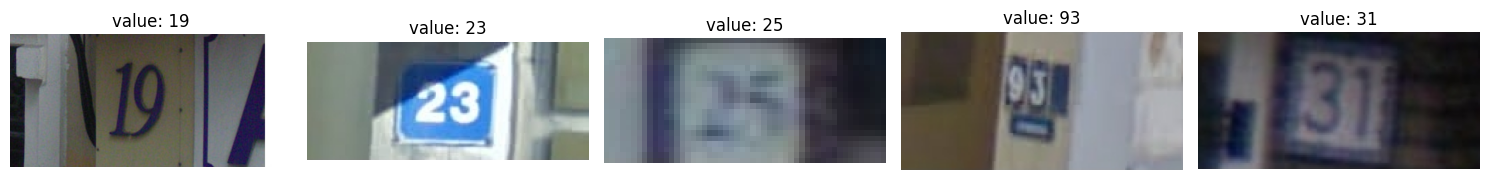

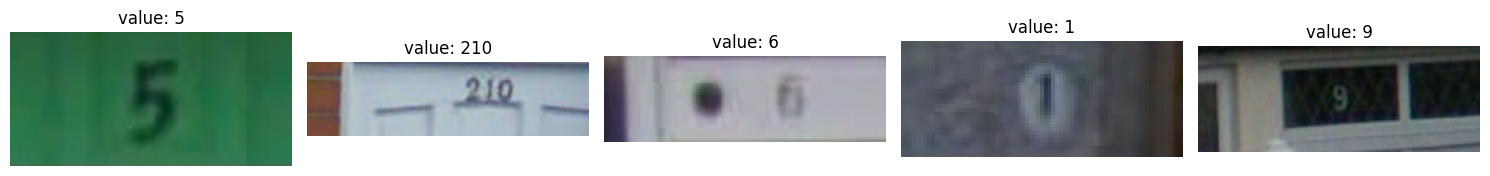

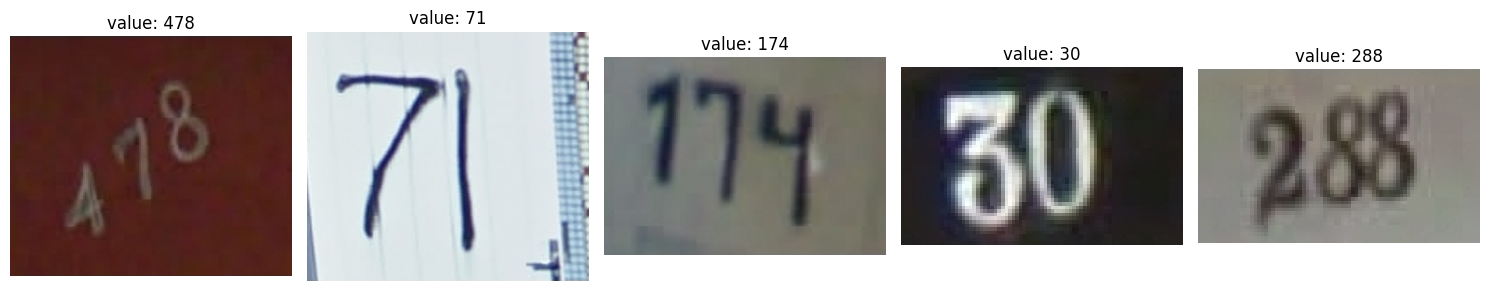

In [6]:
def show_sample_images(df, image_dir, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        img_path = os.path.join(image_dir, df.iloc[i]['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"value: {df.iloc[i]['value']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(train_df, '/kaggle/input/street-view-house-numbers/train/train' , num_samples=5)
show_sample_images(test_df, '/kaggle/input/street-view-house-numbers/test/test' , num_samples=5)
show_sample_images(extra_df, '/kaggle/input/street-view-house-numbers/extra/extra' , num_samples=5)

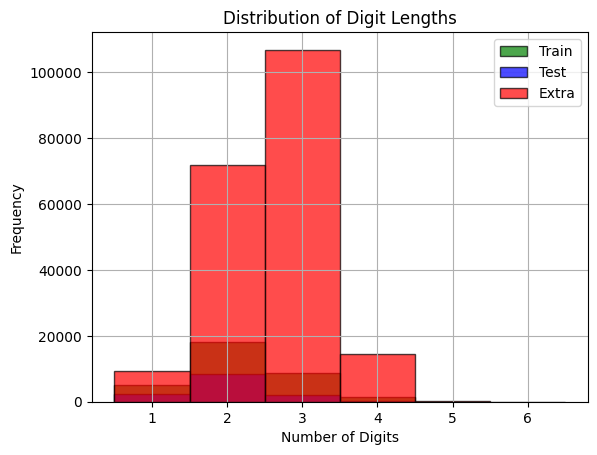

In [7]:
train_lengths = train_df["length"].tolist()
test_lengths = test_df["length"].tolist()
extra_lengths = extra_df["length"].tolist()

plt.hist(train_lengths, bins=range(1, max(train_lengths) + 2), color='green', alpha=0.7, label='Train', edgecolor='black', align='left')
plt.hist(test_lengths, bins=range(1, max(test_lengths) + 2), color='blue', alpha=0.7, label='Test', edgecolor='black', align='left')
plt.hist(extra_lengths, bins=range(1, max(extra_lengths) + 2), color='red', alpha=0.7, label='Extra', edgecolor='black', align='left')

plt.title("Distribution of Digit Lengths")
plt.xlabel("Number of Digits")
plt.ylabel("Frequency")
plt.xticks(range(1, max(max(train_lengths), max(test_lengths), max(extra_lengths)) + 1))
plt.legend()
plt.grid(True)
plt.show()

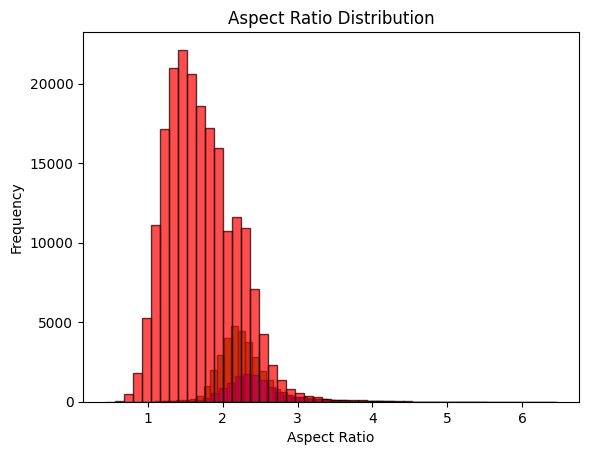

In [8]:
def calculate_aspect_ratio(width, height):
    return width / height if height != 0 else 0
    
train_df['Aspect_Ratio'] = train_df.apply(lambda row: calculate_aspect_ratio(row['width'], row['height']), axis=1)
test_df['Aspect_Ratio'] = test_df.apply(lambda row: calculate_aspect_ratio(row['width'], row['height']), axis=1)
extra_df['Aspect_Ratio'] = extra_df.apply(lambda row: calculate_aspect_ratio(row['width'], row['height']), axis=1)

plt.hist(train_df['Aspect_Ratio'], bins=50, alpha=0.7, color='green', label='Train', edgecolor='black')
plt.hist(test_df['Aspect_Ratio'], bins=50, alpha=0.7, color='blue', label='Test', edgecolor='black')
plt.hist(extra_df['Aspect_Ratio'], bins=50, alpha=0.7, color='red', label='Extra', edgecolor='black')
plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.show()

### Data Augmentation Techniques

In [9]:
def crop_bounding_box(img, bounding_box):
    left, top, right, bottom = bounding_box
    img = np.array(img)
    left, top, right, bottom = map(int, [left, top, right, bottom])
    return img[top:bottom, left:right]

In [10]:
def resize_image(img, dims=(64, 64)):
    return cv2.resize(img, dims)

In [11]:
def convert_to_grayscale(img):
    return np.array(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), dtype=np.float32) / 255.0

In [12]:
def apply_random_rotation(img, angle_range=5):
    angle = randint(-angle_range, angle_range)
    center = (img.shape[1] // 2, img.shape[0] // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, matrix, (img.shape[1], img.shape[0]), 
                          flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

In [13]:
def normalize_image(img):
    mean = np.mean(img, dtype='float32')
    std = np.std(img, dtype='float32', ddof=1)
    std = max(std, 1e-4)
    return (img - mean) / std

In [14]:
def apply_color_perturbations(img, mu=0, sigma=0.0001, eigenvalue_scale=2):
    if len(img.shape) != 3 or img.shape[-1] != 3:
        raise ValueError("apply_color_perturbations expects an RGB image.")

    orig_shape = img.shape

    #Normalize
    img = img.astype(np.float64) / 255.0
    img = img.reshape(-1, 3)

    #Mean center
    mean_centered = img - img.mean(axis=0)

    #Compute covariance and eigen decomposition
    covariance_matrix = np.cov(mean_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    #Sort eigenvalues and eigenvectors
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    #Apply scaling to eigenvalues
    eigenvalues = eigenvalues * eigenvalue_scale

    #Generate perturbations
    random_factors = np.random.normal(mu, sigma, size=3) * eigenvalues
    perturbation = np.dot(eigenvectors, random_factors)

    #Add perturbations to the image
    img += perturbation
    img = np.clip(img, 0, 1)  #Clip values to [0, 1]

    #Convert back to uint8
    img = (img * 255).astype(np.uint8)
    return img.reshape(orig_shape)

In [15]:
import os
import ast
import numpy as np
import cv2

def preprocess_and_store_images(folder, dataframe, dims=(64, 64), grey=False, random_rotate=5, apply_perturbation=True):
    """
    动态读取原图尺寸，保持宽高比，智能缩放再padding到目标尺寸，不做随机裁剪，完整保留图像。
    """
    processed_images = []

    for idx, row in dataframe.iterrows():
        img_path = os.path.join(folder, row['filename'])

        try:
            # 读取整张图片
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None:
                raise ValueError(f"Image at {img_path} could not be read.")

            img = resize_image(img, dims=(dims[0], dims[1]))


            # 随机轻微旋转（可选）
            if random_rotate > 0:
                img = apply_random_rotation(img, angle_range=random_rotate)

            # 颜色扰动（可选）
            if not grey and apply_perturbation:
                img = apply_color_perturbations(img)

            # 灰度转换（可选）
            if grey:
                img = convert_to_grayscale(img)

            processed_images.append(img)

        except Exception as e:
            print(f"Error processing image {img_path}: {e}")

    return np.array(processed_images)


In [17]:
def compare_images(folder, dataframe, processed_images, num_samples=5, grey=False):
    num_samples = min(num_samples, len(dataframe))
    fig, axs = plt.subplots(num_samples, 2, figsize=(12, num_samples * 5))
  
    if num_samples == 1:
        axs = np.expand_dims(axs, axis=0)

    for idx in range(num_samples):
        row = dataframe.iloc[idx]
        img_path = os.path.join(folder, row['filename'])
        original_img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        processed_img = processed_images[idx]
        
        axs[idx, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        axs[idx, 0].axis("off")
        axs[idx, 0].set_title("Original Image (Color)")
        axs[idx, 1].imshow(processed_img.squeeze(), cmap="gray" if grey else None)
        axs[idx, 1].axis("off")
        axs[idx, 1].set_title("Processed Image")
    
    plt.tight_layout()
    plt.show()

133


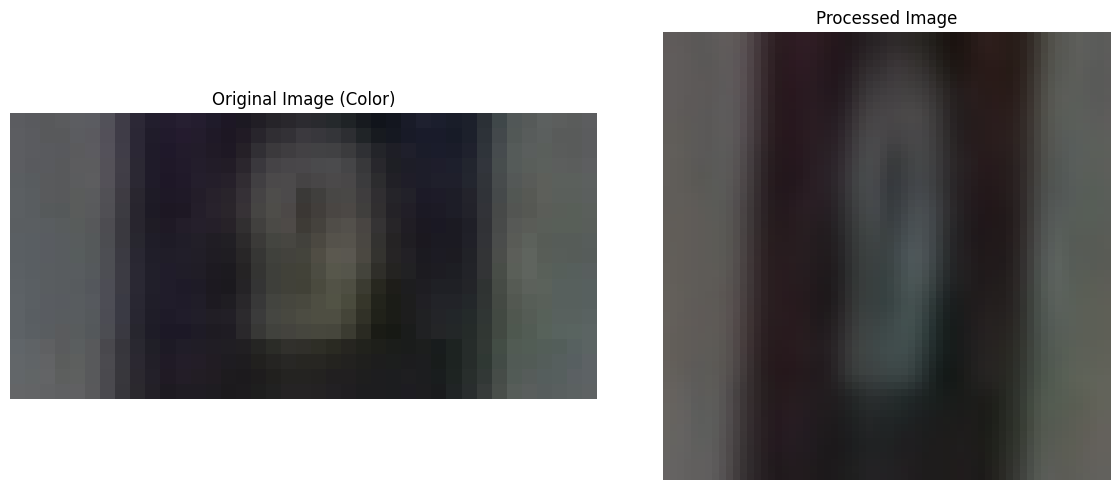

In [18]:
random_idx = np.random.choice(train_df.index)
print(random_idx)
random_image_row = train_df.iloc[random_idx:random_idx+1]
processed_images = preprocess_and_store_images("/kaggle/input/street-view-house-numbers/train/train", random_image_row, dims=(64, 64))
compare_images("/kaggle/input/street-view-house-numbers/train/train", random_image_row, processed_images)

### Dataset Creation for Training

In [19]:
def preprocess_digits_column(df):
    df['digits'] = df['digits'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df
train_df = preprocess_digits_column(train_df)
test_df = preprocess_digits_column(test_df)
extra_df = preprocess_digits_column(extra_df)

In [20]:
# def generate_dataset(df, folder):
#     dataset = np.ndarray([len(df), 64, 64], dtype='float32')
#     labels = np.zeros([len(df), 5], dtype=int) 
#     for i in range(len(df)):
#         filename = df.loc[i, 'filename']
#         fullname = os.path.join(folder, filename)
#         im = Image.open(fullname)
        
#         digits = df.loc[i, 'digits']
#         box = df.loc[i, 'box']
     
#         if isinstance(box, str):
#             box = eval(box) 
#         num_digits = len(digits)
#         for j in range(min(num_digits, 5)): 
#             labels[i, j] = digits[j] if digits[j] != 10 else 0
        
#         if num_digits > 5:
#             print(f'Warning: Image {i} has more than 5 digits. Only the first 5 digits will be used.')
    
#         if len(box) == 4: 
#             left, top, width, height = box
#         else:
#             raise ValueError(f"Box format is incorrect for index {i}: {box}")
            
#         im_left, im_top = left, top
#         im_width, im_height = width, height
      
#         im_top = max(0, np.floor(im_top - 0.1 * im_height))
#         im_left = max(0, np.floor(im_left - 0.1 * im_width))
#         im_bottom = min(im.size[1], np.ceil(im_top + 1.2 * im_height))
#         im_right = min(im.size[0], np.ceil(im_left + 1.2 * im_width))
       
#         im = im.crop((im_left, im_top, im_right, im_bottom)).resize([64, 64], Image.Resampling.LANCZOS)
#         im = np.array(im.convert('L'), dtype='float32')  
#         mean = np.mean(im, dtype='float32')
#         std = np.std(im, dtype='float32', ddof=1)
#         std = max(std, 1e-4)
#         im = (im - mean) / std
       
#         dataset[i, :, :] = im
        
#     return dataset, labels

In [21]:
# def generate_dataset(df, folder):
#     dataset = np.ndarray([len(df), 64, 64], dtype='float32')
#     labels = np.zeros([len(df), 5], dtype=int) 
#     for i in range(len(df)):
#         filename = df.loc[i, 'filename']
#         fullname = os.path.join(folder, filename)
#         im = Image.open(fullname)
        
#         digits = df.loc[i, 'digits']
#         box = df.loc[i, 'box']
     
#         if isinstance(box, str):
#             box = eval(box) 
#         num_digits = len(digits)
#         for j in range(min(num_digits, 5)): 
#             labels[i, j] = digits[j] if digits[j] != 10 else 0
        
#         if num_digits > 5:
#             print(f'Warning: Image {i} has more than 5 digits. Only the first 5 digits will be used.')
    
#         if len(box) == 4: 
#             left, top, width, height = box
#         else:
#             raise ValueError(f"Box format is incorrect for index {i}: {box}")
            
#         im_left, im_top = left, top
#         im_width, im_height = width, height
      
#         im_top = max(0, np.floor(im_top - 0.1 * im_height))
#         im_left = max(0, np.floor(im_left - 0.1 * im_width))
#         im_bottom = min(im.size[1], np.ceil(im_top + 1.2 * im_height))
#         im_right = min(im.size[0], np.ceil(im_left + 1.2 * im_width))
       
#         im = crop_bounding_box(im, (im_left, im_top, im_right, im_bottom))
#         im = Image.fromarray(im)
#         im = im.resize((64, 64), Image.LANCZOS)

#         im = np.array(im.convert('RGB'), dtype='float32')
#         im = convert_to_grayscale(im)

#         im = normalize_image(im)
        
#         dataset[i, :, :] = im
        
#     return dataset, labels

In [22]:
# train_folder = "/kaggle/input/street-view-house-numbers/train/train"
# test_folder = "/kaggle/input/street-view-house-numbers/test/test"
# extra_folder = "/kaggle/input/street-view-house-numbers/extra/extra"

# train_dataset, train_labels = generate_dataset(train_df, train_folder)
# print(train_dataset.shape, train_labels.shape)

# test_dataset, test_labels = generate_dataset(test_df, test_folder)
# print(test_dataset.shape, test_labels.shape)

# extra_dataset, extra_labels = generate_dataset(extra_df, extra_folder)
# print(extra_dataset.shape, extra_labels.shape)

In [23]:
# train_dataset = np.delete(train_dataset, 29929, axis=0)
# train_labels = np.delete(train_labels, 29929, axis=0)

In [24]:
# print(train_dataset.shape, train_labels.shape)

In [25]:
# print("Training dataset shape:", extra_dataset.shape)
# print("Training labels shape:", extra_labels.shape)
# print("Test dataset shape:", train_dataset.shape)
# print("Test labels shape:", train_labels.shape)
# print("Validation dataset shape:", test_dataset.shape)
# print("Validation labels shape:", test_labels.shape)

# pickle_file = 'SVHN_multi.pickle'

# try:
#     with open(pickle_file, 'wb') as f:
#         save = {
#             'train_dataset': extra_dataset,
#             'train_labels': extra_labels,
#             'valid_dataset': train_dataset,
#             'valid_labels': train_labels,
#             'test_dataset': test_dataset,
#             'test_labels': test_labels,
#         }
#         pickle.dump(save, f, pickle.HIGHEST_PROTOCOL)
#     print(f'Data saved successfully to {pickle_file}')
# except Exception as e:
#     print(f'Unable to save data to {pickle_file}: {e}')
#     raise

# statinfo = os.stat(pickle_file)
# print('Compressed pickle size:', statinfo.st_size)

In [26]:
possible_classes = 11

def convert_labels(labels):
    dig0_arr = np.ndarray(shape=(len(labels),possible_classes))
    dig1_arr = np.ndarray(shape=(len(labels),possible_classes))
    dig2_arr = np.ndarray(shape=(len(labels),possible_classes))
    dig3_arr = np.ndarray(shape=(len(labels),possible_classes))
    dig4_arr = np.ndarray(shape=(len(labels),possible_classes))
    
    for index,label in enumerate(labels):
        dig0_arr[index,:] = to_categorical(label[0],possible_classes)
        dig1_arr[index,:] = to_categorical(label[1],possible_classes)
        dig2_arr[index,:] = to_categorical(label[2],possible_classes)
        dig3_arr[index,:] = to_categorical(label[3],possible_classes)
        dig4_arr[index,:] = to_categorical(label[4],possible_classes)
        
    return [dig0_arr,dig1_arr,dig2_arr,dig3_arr,dig4_arr]

In [27]:
def prep_data_keras(img_data):
    img_data = img_data.reshape(len(img_data), 64, 64, 1)
    img_data = img_data.astype('float32')
    img_data /= 255
    return img_data

In [28]:
def calculate_acc(predictions,real_labels):
    individual_counter = 0
    global_sequence_counter = 0
    coverage_counter = 0
    confidence = 0.7
    for i in range(0,len(predictions[0])):
        sequence_counter = 0 
        
        for j in range(0,5):
            
            if np.argmax(predictions[j][i]) == np.argmax(real_labels[j][i]):
                individual_counter += 1
                sequence_counter += 1
            if predictions[j][i][np.argmax(predictions[j][i])] >= confidence:
                coverage_counter += 1
        
        if sequence_counter == 5:
            global_sequence_counter += 1
         
    ind_accuracy = individual_counter / float(len(predictions[0]) * 5)
    global_accuracy = global_sequence_counter / float(len(predictions[0]))
    coverage = coverage_counter / float(len(predictions[0]) * 5)
    
    return ind_accuracy,global_accuracy, coverage

### CRNN + CTC Loss

In [29]:
pickle_file = '/kaggle/input/svhn-preprocess-data-64x64/SVHN_multi.pickle'

with open(pickle_file, 'rb') as f:
    save = pickle.load(f)
    train_dataset = save['train_dataset']
    train_labels = save['train_labels']
    valid_dataset = save['valid_dataset']
    valid_labels = save['valid_labels']
    test_dataset = save['test_dataset']
    test_labels = save['test_labels']
    del save
    print('Training set', train_dataset.shape, train_labels.shape)
    print('Validation set', valid_dataset.shape, valid_labels.shape)
    print('Test set', test_dataset.shape, test_labels.shape)

Training set (202353, 64, 64) (202353, 5)
Validation set (33401, 64, 64) (33401, 5)
Test set (13068, 64, 64) (13068, 5)


In [30]:
train_dataset = train_dataset[:28000]
train_labels = train_labels[:28000]

valid_dataset = valid_dataset[:4000]
valid_labels = valid_labels[:4000]

test_dataset = test_dataset[:8000]
test_labels = test_labels[:8000]

In [31]:
train_labels.shape

(28000, 5)

In [32]:
train_labels[0]

array([4, 7, 8, 0, 0])

In [33]:
type(train_labels[0])

numpy.ndarray

In [34]:
train_labels = train_labels.tolist()
valid_labels = valid_labels.tolist()
test_labels = test_labels.tolist()

In [35]:
type(train_labels[0])

list

In [36]:
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_dataset, train_labels))
train_dataset = train_dataset.shuffle(buffer_size=len(train_dataset)).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((valid_dataset, valid_labels))
valid_dataset = valid_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_dataset, test_labels))
test_dataset = test_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

In [37]:
train_iter = iter(train_dataset)
valid_iter = iter(valid_dataset)
test_iter = iter(test_dataset)

train_sample = next(train_iter)
valid_sample = next(valid_iter)
test_sample = next(test_iter)

def display_sample(dataset_sample, dataset_name):
    print(f"\n{dataset_name} Sample Data:")
    print("Image (first sample):")
    print(dataset_sample[0][0].numpy())
    print("Label (first sample):")
    print(dataset_sample[1][0].numpy())

display_sample(train_sample, "Train")
display_sample(valid_sample, "Validation")
display_sample(test_sample, "Test")


Train Sample Data:
Image (first sample):
[[0.4234417  0.45323187 0.48302248 ... 0.41420668 0.3248366  0.25328052]
 [0.48302248 0.48302248 0.54260236 ... 0.3248366  0.29504597 0.25328052]
 [0.60218316 0.6617631  0.6319733  ... 0.20567593 0.1758853  0.16391002]
 ...
 [0.23918936 0.26898    0.3319562  ... 0.5511822  0.5035772  0.5035772 ]
 [0.39704788 0.42683804 0.4302344  ... 0.56008947 0.5124844  0.49160188]
 [0.47783855 0.5251158  0.4953256  ... 0.55490595 0.5162086  0.4864184 ]]
Label (first sample):
[1 4 7 0 0]

Validation Sample Data:
Image (first sample):
[[-0.72024333 -0.72169167 -0.66294783 ...  3.0550623   3.1129951
   3.1129951 ]
 [-0.6770062  -0.7217109  -0.6802697  ...  3.0550623   3.1129951
   3.1129951 ]
 [-0.69222313 -0.7028249  -0.6311427  ...  3.0550623   3.1129951
   3.1129951 ]
 ...
 [-0.42737383 -0.42673647 -0.28829643 ...  3.0801473   3.1129951
   3.1129951 ]
 [-0.47796842 -0.4566493  -0.28084245 ...  3.0743735   3.1129951
   3.1129951 ]
 [-0.4502572  -0.4755352  -0

In [38]:
max_length = 5
batch_size = 32
nb_classes = 11

def attention_module(inputs):
    x = Conv2D(1, (1, 1))(inputs)
    x = Activation('sigmoid')(x)
    return multiply([inputs, x])

In [39]:
input_data = Input(shape=(64, 64, 1), name='input_image')

x = GaussianNoise(0.01)(input_data)

x = Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

x = Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.35)(x)

x = attention_module(x)

x = Reshape((-1, x.shape[-1]))(x)

for _ in range(4):
    x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3,
                      recurrent_dropout=0.1,
                      kernel_initializer='he_normal',
                      recurrent_initializer='orthogonal',
                      bias_initializer='zeros',
                      unit_forget_bias=True,
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)))(x)
    x = LayerNormalization()(x)

x = Lambda(lambda x: tf.cast(x, tf.float32))(x)
output = Dense(nb_classes, activation='softmax', name='output')(x)

def ctc_loss_with_label_smoothing(y_true, y_pred, smoothing=0.1):
    batch_size = tf.shape(y_pred)[0]
    input_length = tf.fill((batch_size, 1), tf.shape(y_pred)[1])
    label_length = tf.fill((batch_size, 1), max_length)
    
    nb_classes = tf.shape(y_pred)[-1]
    y_pred = y_pred * (1 - smoothing) + (smoothing / tf.cast(nb_classes, tf.float32))
    
    return ctc_batch_cost(y_true, y_pred, input_length, label_length)
    
def sequence_accuracy_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred, tf.float32)
    decoded, _ = ctc_decode(
        y_pred, 
        input_length=tf.fill((tf.shape(y_pred)[0],), tf.shape(y_pred)[1])
    )
    decoded_tensor = tf.cast(decoded[0], tf.int64)
    y_true = tf.cast(y_true, tf.int64)
    
    decoded_tensor = decoded_tensor[:, :max_length]
    
    return tf.reduce_mean(tf.cast(tf.reduce_all(tf.equal(decoded_tensor, y_true), axis=1), tf.float32))

model = Model(inputs=input_data, outputs=output, name="SVHN_OCR_model")

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer,
             loss=ctc_loss_with_label_smoothing,
             metrics=[sequence_accuracy_metric])

model.summary()

Model: "SVHN_OCR_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 64, 64, 1) │          0 │ input_image[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        288 │ gaussian_noise[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,432 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ activation_3[0][

 Total params: 6,959,916 (26.55 MB)

 Trainable params: 6,957,996 (26.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [40]:
def cosine_decay_with_warmup(epoch):
    initial_learning_rate = 0.001
    warmup_epochs = 5
    decay_epochs = 20
    
    if epoch < warmup_epochs:
        return initial_learning_rate * (epoch + 1) / warmup_epochs
    else:
        return initial_learning_rate * 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / decay_epochs))

callbacks = [
    LearningRateScheduler(cosine_decay_with_warmup),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        min_delta=1e-4
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_delta=1e-4,
        min_lr=1e-6
    )
]
history = model.fit(
    train_dataset,
    epochs=40,
    validation_data=valid_dataset,
    callbacks=callbacks
)

Epoch 1/40


2025-04-27 13:19:16.302848: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/SVHN_OCR_model_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


875/875 ━━━━━━━━━━━━━━━━━━━━ 182s 183ms/step - loss: 11.1018 - sequence_accuracy_metric: 0.0000e+00 - val_loss: 8.9201 - val_sequence_accuracy_metric: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 2/40
875/875 ━━━━━━━━━━━━━━━━━━━━ 158s 180ms/step - loss: 8.6641 - sequence_accuracy_metric: 0.0039 - val_loss: 7.3936 - val_sequence_accuracy_metric: 0.0810 - learning_rate: 4.0000e-04
Epoch 3/40
875/875 ━━━━━━━━━━━━━━━━━━━━ 158s 181ms/step - loss: 6.9222 - sequence_accuracy_metric: 0.0888 - val_loss: 6.2510 - val_sequence_accuracy_metric: 0.3232 - learning_rate: 6.0000e-04
Epoch 4/40
875/875 ━━━━━━━━━━━━━━━━━━━━ 159s 181ms/step - loss: 5.2926 - sequence_accuracy_metric: 0.3297 - val_loss: 5.5345 - val_sequence_accuracy_metric: 0.3947 - learning_rate: 8.0000e-04
Epoch 5/40
875/875 ━━━━━━━━━━━━━━━━━━━━ 158s 180ms/step - loss: 4.5059 - sequence_accuracy_metric: 0.4530 - val_loss: 5.1972 - val_sequence_accuracy_metric: 0.3877 - learning_rate: 0.0010
Epoch 6/40
875/875 ━━━━━━━━━━━━━━━━━━━━ 158s 1

In [41]:
predictions = model.predict(test_dataset, verbose=1)

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


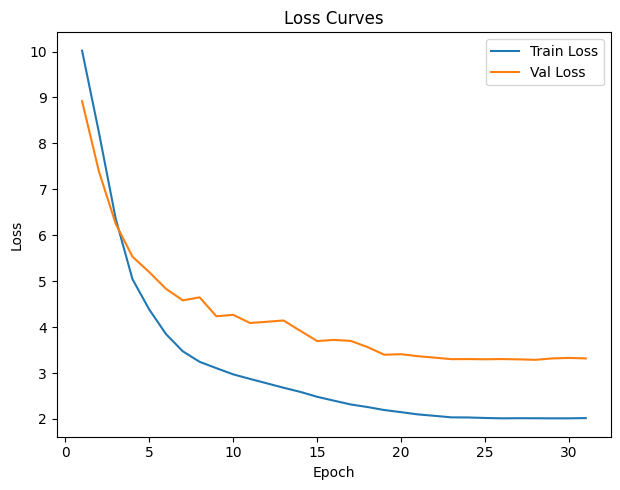

In [44]:
# （2）在 fit 之后插入以下代码来画图
import matplotlib.pyplot as plt

# 从 history 中取出各 epoch 的指标
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
sequence_accuracy_metric  = history.history.get('sequence_accuracy_metric')      # 如果用的 metric 名称是 'accuracy'
val_sequence_accuracy_metric    = history.history.get('val_sequence_accuracy_metric')

epochs = range(1, len(train_loss) + 1)

# （3）画出 Loss 曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()


plt.xlabel('Epoch')
plt.title('Loss Curves')

plt.tight_layout()
plt.show()

In [45]:
predictions.shape

(8000, 16, 11)

In [46]:
predictions = tf.cast(predictions, tf.float32)

decoded, _ = tf.keras.backend.ctc_decode(
    predictions, 
    input_length=tf.fill((predictions.shape[0],), predictions.shape[1]), 
    greedy=True
)
decoded_sequences = decoded[0].numpy()
decoded_labels = [np.clip(seq[:5], 0, None) for seq in decoded_sequences]

In [48]:
ind_acc = np.mean([np.equal(decoded_labels[i], test_labels[i]) for i in range(len(decoded_labels))])
glob_acc = np.mean([np.array_equal(decoded_labels[i], test_labels[i]) for i in range(len(decoded_labels))])
coverage = np.mean([np.sum(np.equal(decoded_labels[i], test_labels[i])) / 5 for i in range(len(decoded_labels))])

print("The sequence prediction accuracy is {:.2f} %".format(glob_acc * 100))

The sequence prediction accuracy is 64.18 %
